In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,roc_auc_score, auc)

from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn # kerangka model
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('default of credit card clients.csv')
df.head(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,6,50000,1,1,2,37,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
6,7,500000,1,1,2,29,0,0,0,0,...,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
7,8,100000,2,2,2,23,0,-1,-1,0,...,221,-159,567,380,601,0,581,1687,1542,0
8,9,140000,2,3,1,28,0,0,2,0,...,12211,11793,3719,3329,0,432,1000,1000,1000,0
9,10,20000,1,3,2,35,-2,-2,-2,-2,...,0,13007,13912,0,0,0,13007,1122,0,0


In [3]:
df.shape

(30000, 25)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

# Missing Value / Duplicate value 

In [5]:
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

# EDA

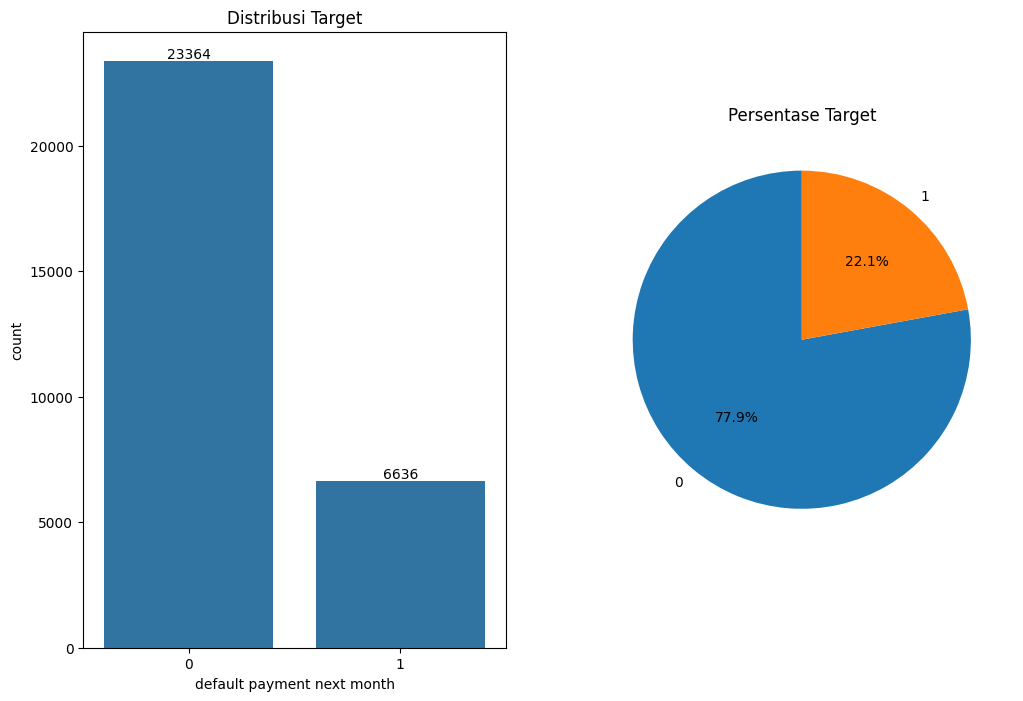

In [7]:
# Distribusi default payment next month (target)
fig, axes = plt.subplots(1,2, figsize=(12,8))

# Barplot
sns.countplot(data=df, x='default payment next month', ax = axes[0])
for i in axes[0].containers:
    axes[0].bar_label(i)
axes[0].set_title('Distribusi Target')

# piechart
target_count = df['default payment next month'].value_counts()
plt.pie(target_count, labels=target_count.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Persentase Target')

plt.show()

Dari visualisasi target, terlihat bahwa data lebih mayoritas ke nasabah yang tidak melakukan default(0), sedangkan sebagian kecil lainnya melakukan default(1). Ini menunjukkan adanya ketidakseimbangan kelas (imbalanced dataset).
Hal ini bisa mempengaruhi perfoma model terutama memprediksi kelas minoritas(default), jadi nanti kita akan menggunakna teknik SMOTE (Synthetic Minority Oversampling Technique) utk mengatasi ketidakseimbangan data.

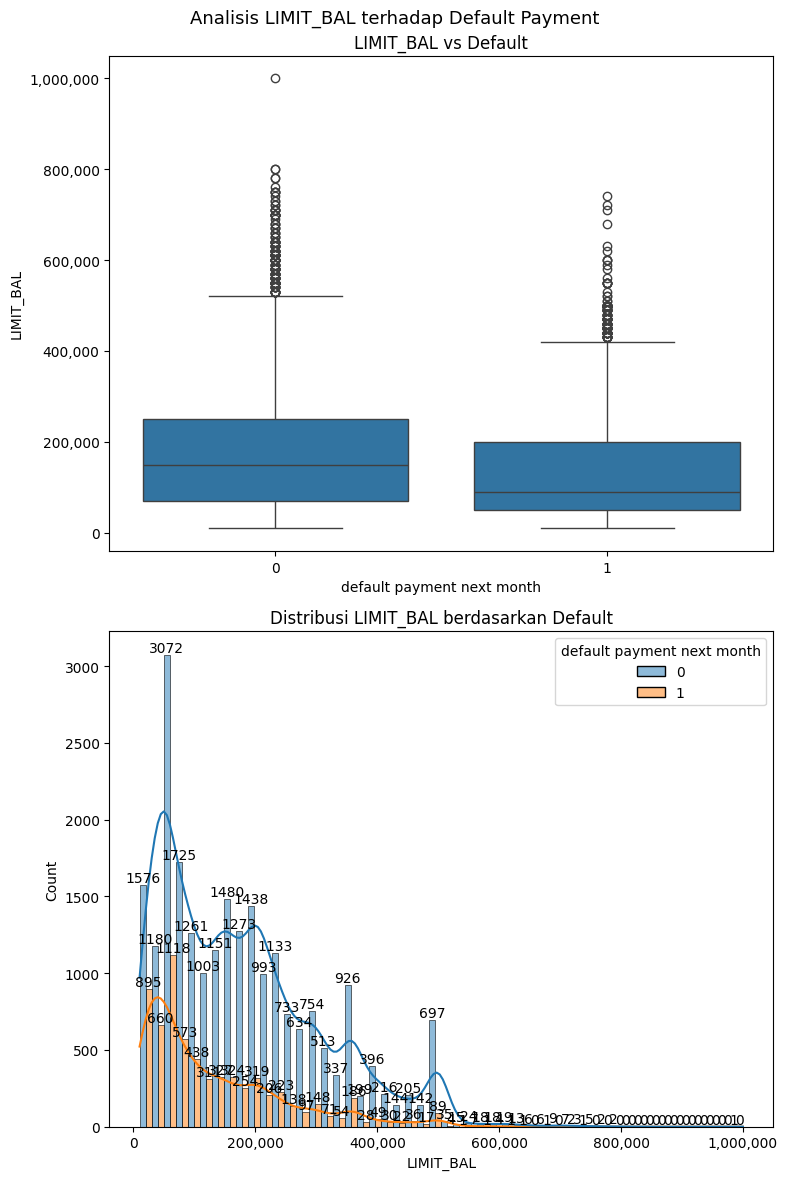

In [8]:
# Visual Analisis LIMIT_BAL terhadap Default Payment
import matplotlib.ticker as ticker
fig , axes = plt.subplots(2,1, figsize=(8,12))
fig.suptitle('Analisis LIMIT_BAL terhadap Default Payment', fontsize=13)

# boxplot
sns.boxplot(data=df, x='default payment next month', y='LIMIT_BAL', ax=axes[0])
axes[0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
axes[0].set_title('LIMIT_BAL vs Default')

# histogram
sns.histplot(data=df, x='LIMIT_BAL', hue='default payment next month', bins=50, ax=axes[1], kde=True, multiple='dodge')
axes[1].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
for i in axes[1].containers:
    axes[1].bar_label(i)
axes[1].set_title('Distribusi LIMIT_BAL berdasarkan Default', fontsize=12)

plt.tight_layout()
plt.show()

Visualisasi menunjukkan bahwa nasabah yang melakukan default (1) cenderung memiliki LIMIT_BAL yang lebih rendah dibandingkan dengan nasabah yang tidak default (0).
Hal ini terlihat dari boxplot, di mana median LIMIT_BAL pada kelompok default lebih kecil. Histogram juga menunjukkan bahwa sebagian besar data terkonsentrasi pada limit kredit rendah, terutama pada nasabah yang melakukan default. Selain itu terlihat beberapa outliar tinggi di boxplot, namun nilainya masih dlm batas wajar jadi tidak perlu ada penanganan outliar  

Dengan demikian, LIMIT_BAL memiliki pengaruh terhadap kemungkinan default, di mana semakin kecil limit kredit, semakin tinggi risiko terjadinya default.


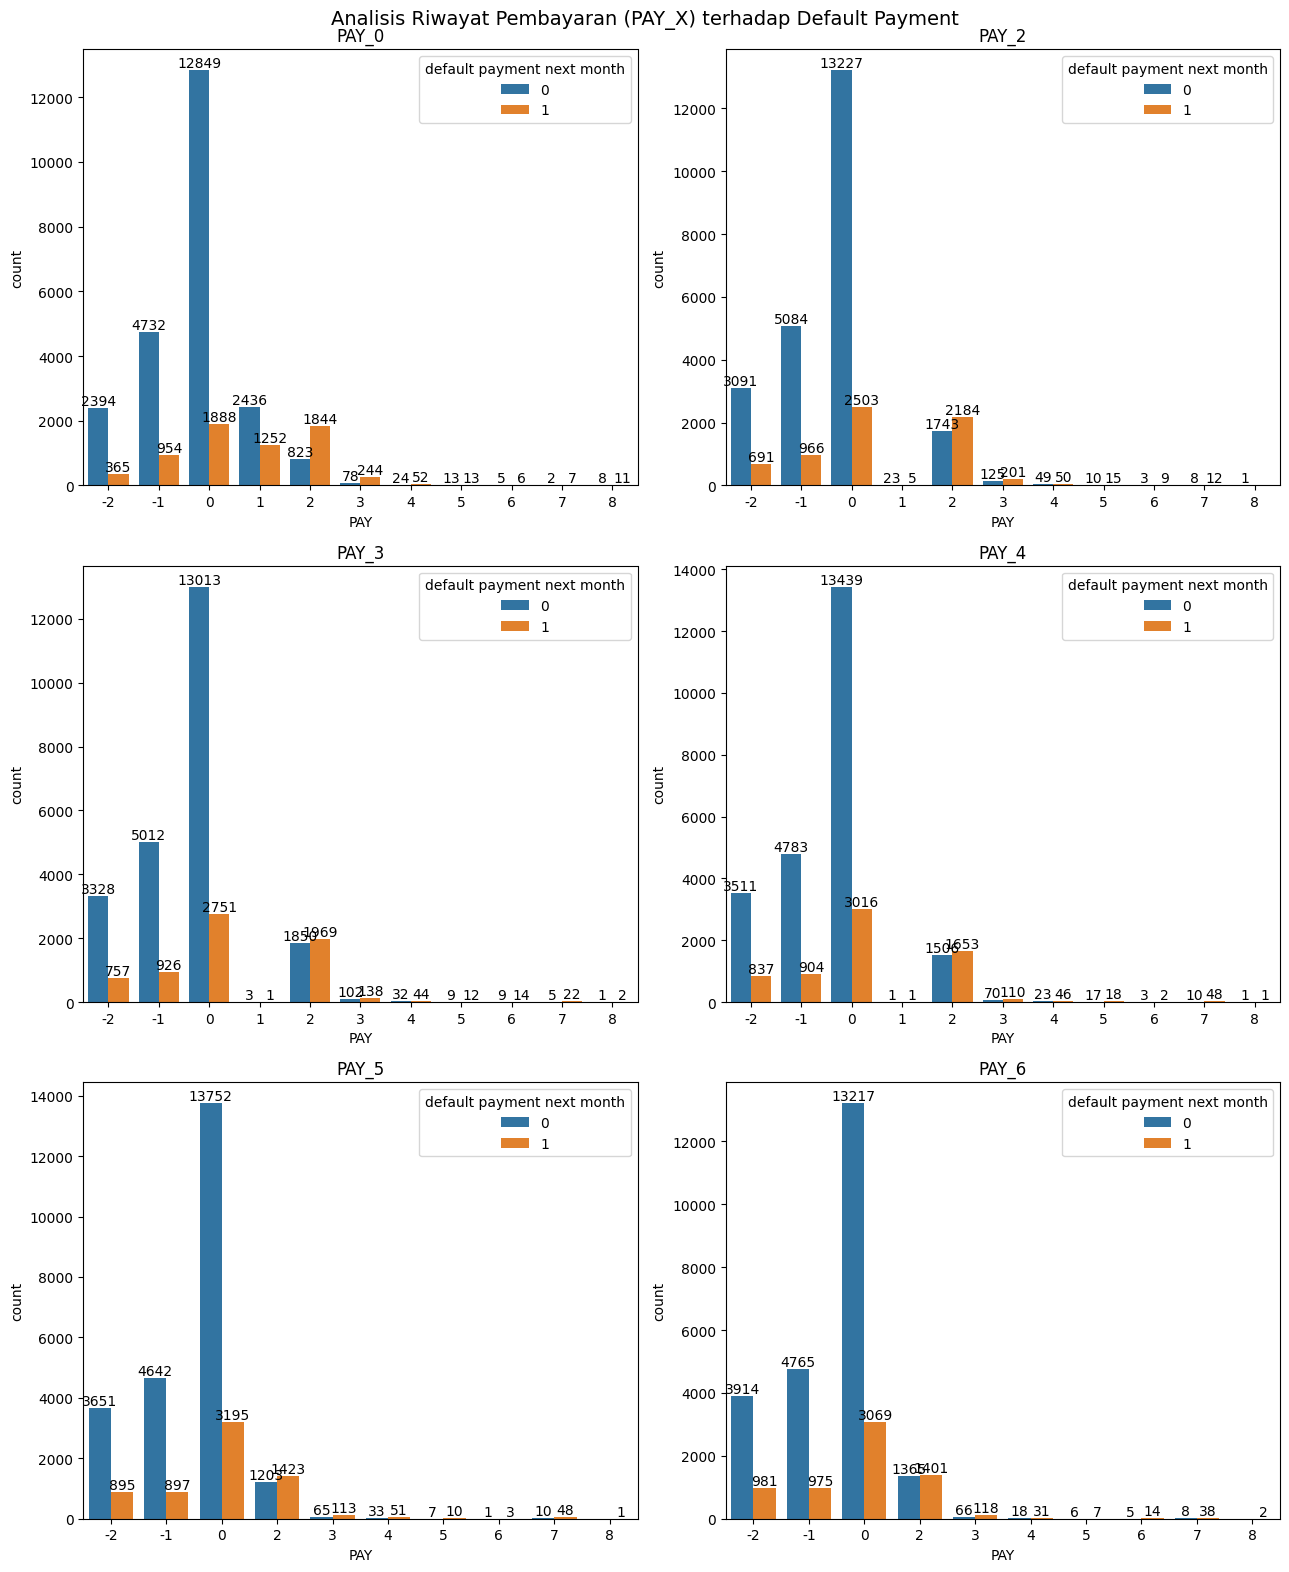

In [9]:
# visual riwayat pembayaran (PAX_X) vs Default Payment
fig, axes = plt.subplots(3, 2, figsize=(13,16))
fig.suptitle('Analisis Riwayat Pembayaran (PAY_X) terhadap Default Payment', fontsize=14)
axes = axes.flatten() # utk membuat banyak subplot 

pay_col = [
    'PAY_0',
    'PAY_2',
    'PAY_3',
    'PAY_4',
    'PAY_5',
    'PAY_6'
]

for i, col in enumerate(pay_col):
    sns.countplot(data=df, x=col, hue='default payment next month', ax=axes[i])
    for j in axes[i].containers:
        axes[i].bar_label(j)
    axes[i].set_title(col)
    axes[i].set_xlabel('PAY')

plt.tight_layout()
plt.show()

Berdasarkan visualisasi, sebagian besar nasabah melakukan pembayaran tepat waktu (-2 sampai 0). Selain itu, nasabah dengan pembayaran lancar cenderung tidak mengalami default, sedangkan keterlambatan pembayaran meningkatkan risiko default.


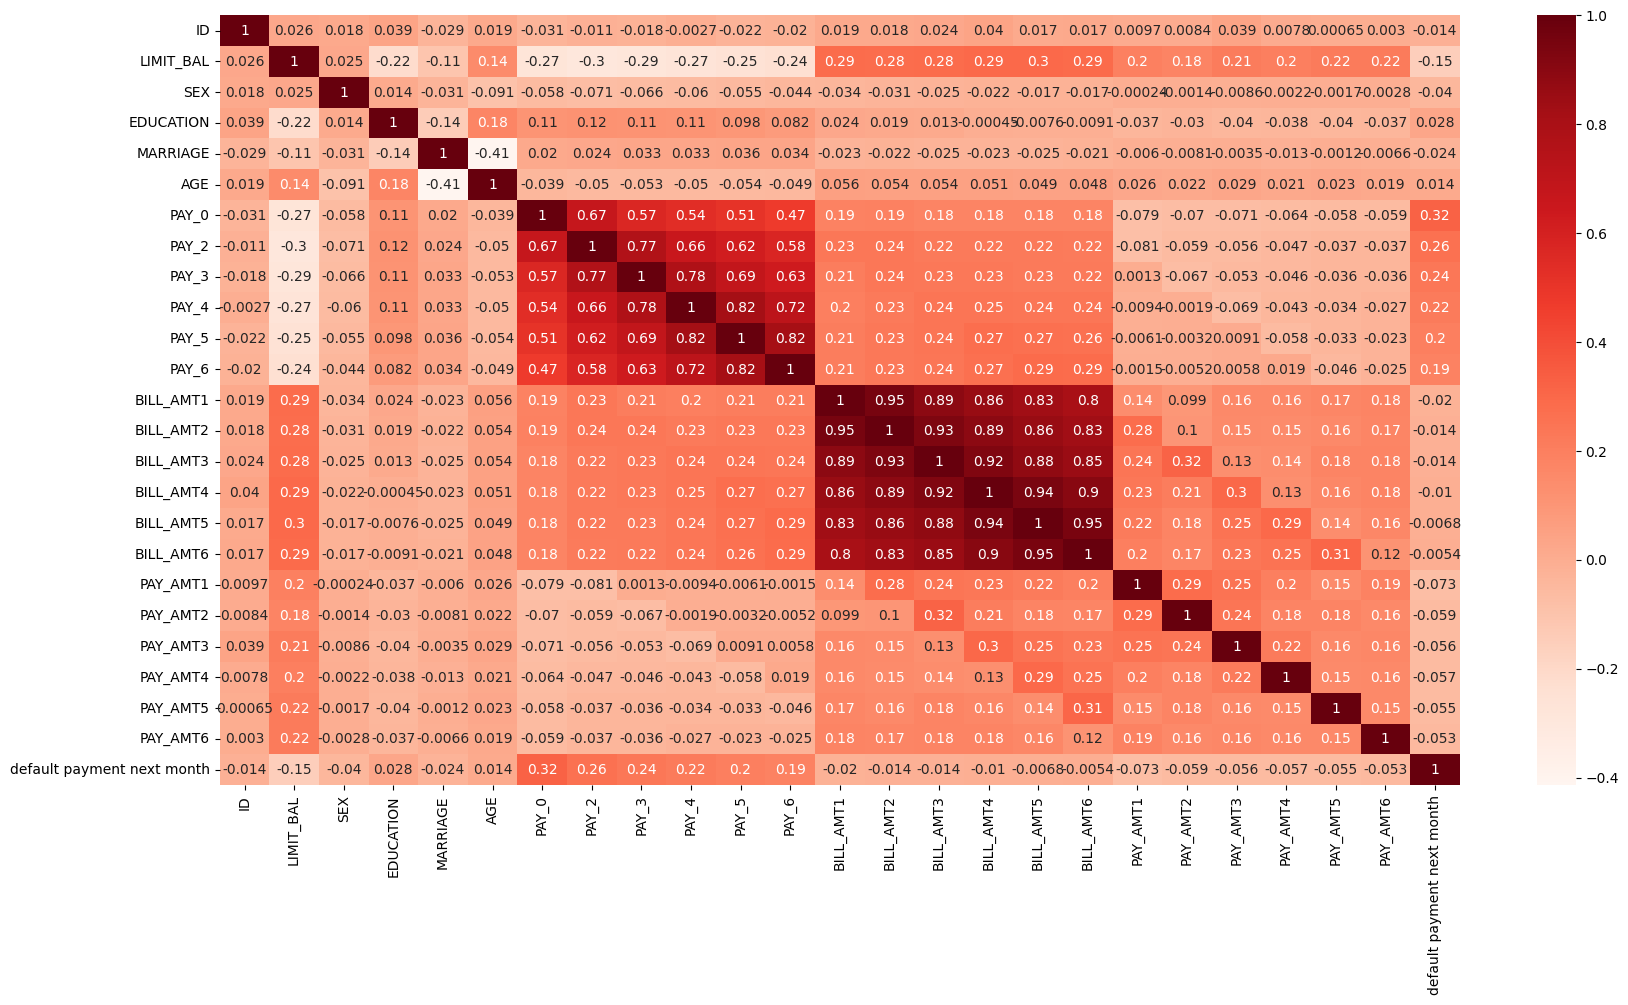

In [10]:
# heatmap (melihat korelasi antar feature)
plt.figure(figsize=(20,10))

heat_cor = df.corr()
sns.heatmap(data=heat_cor, annot=True, cmap='Reds')
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Pada visual menampilkan seberapa kuat hubungan antar fitur pada dataset, kalau dilihat atribut default payment itu kuat hubungannya dengan atribut PAY_X yaitu dengan nilai korelasi berkisar antara 0.19 hingga 0.32, ini menunjukkan bahwa keterlambatan pembayaran memiliki cukup pengaruh yang terhadap default, dan yang hubungan default payment paling lemah itu dengan atribut BILL_ATM_X

# Feature Selection

In [11]:
# feature selection 
df_bersih = df.copy()
df_bersih.drop(columns='ID', inplace=True)
df_bersih.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### Feature Engineering

In [12]:
#### PAY_X mean
mean_pay = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
df_bersih['PAY_MEAN'] = df_bersih[mean_pay].mean(axis=1)

# Pay ration bill_total / pay_total
df_bersih['bill_total'] =df_bersih[['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4',
                                   'BILL_AMT5','BILL_AMT6']].sum(axis=1)
df_bersih['pay_total'] = df_bersih[['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4',
                                    'PAY_AMT5','PAY_AMT6']].sum(axis=1)

df_bersih['PAY_RATIO'] = df_bersih['pay_total'] / (df_bersih['bill_total'] + 1)
df_bersih.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,PAY_MEAN,bill_total,pay_total,PAY_RATIO
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,1,-0.333333,7704,689,0.089422
1,120000,2,2,2,26,-1,2,0,0,0,...,1000,1000,1000,0,2000,1,0.500000,17077,5000,0.292774
2,90000,2,2,2,34,0,0,0,0,0,...,1500,1000,1000,1000,5000,0,0.000000,101653,11018,0.108387
3,50000,2,2,1,37,0,0,0,0,0,...,2019,1200,1100,1069,1000,0,0.000000,231334,8388,0.036259
4,50000,1,2,1,57,-1,0,-1,0,0,...,36681,10000,9000,689,679,0,-0.333333,109339,59049,0.540049


# Split data Training dan Test

In [13]:
# memilih fitur training
# select_fitur = [
#     'LIMIT_BAL','AGE','SEX','EDUCATION','MARRIAGE',
#     'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
#     'PAY_MEAN','PAY_RATIO', 'bill_total', 'pay_total'
# ]

# split data
# X = df_bersih[select_fitur]
X = df_bersih.drop(columns=['default payment next month'])
y = df_bersih['default payment next month']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Model ini menggunakan fitur hasil seleksi dan feature engineering. Variabel PAY_X tetap dipakai karena memiliki pengaruh kuat terhadap default, sedangkan fitur tambahan seperti PAY_MEAN dan PAY_RATIO digunakan untuk merangkum pola keterlambatan dan kemampuan pembayaran nasabah.
Fitur BILL_AMT dan PAY_AMT tidak dipakai karena bersifat redundant dan kurang berpengaruh terhadap default, sehingga digantikan dengan fitur yang lebih ringkas dan informatif (hanya asumsi saya)

**Ralat:**

Untuk fitur trainnya saya pakai semuanya kecuali ['default payment next month'] tidak jadi menggunakna beberapa fitur saja 

## Normalisasi (Scaling)

In [14]:
scaler = StandardScaler()

# hasilnya akan menjadi numpy array 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE

In [15]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# lihat hasil smote
print("Sebelum SMOTE")
print(y_train.value_counts())
print("\nSetelah SMOTE")
print(y_train_smote.value_counts())

Sebelum SMOTE
default payment next month
0    18691
1     5309
Name: count, dtype: int64

Setelah SMOTE
default payment next month
0    18691
1    18691
Name: count, dtype: int64


In [16]:
print(type(y_test))
print(type(X_test))
print(type(X_train_scaled))
print(type(X_test_scaled))
print(type(X_train_smote))
print(type(y_train_smote))

<class 'pandas.Series'>
<class 'pandas.DataFrame'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'pandas.Series'>


## Ubah Data ke Tensor

In [17]:
# ubah semua data dalam bentuk tensor agar dataset bisa di gunakan model  
X_train_tensor = torch.tensor(X_train_smote, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_smote.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

## Dataset & Dataloader

In [18]:
# menggabungkan data train dan test 
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Arsitektur Model

In [19]:
# model neural network
class CreditModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            # Blok pertama
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256), # menormalisas agar model stabil dan cepat 
            nn.LeakyReLU(0.1), # utk pola non linear / gradienya tetap ada 
            nn.Dropout(0.4),

            # blok kedua
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),

            # blok ketiga
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),

            # blok keempat 
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(),

            # output layer
            nn.Linear(32, 1),
            # nn.Sigmoid()
        )

        self._init_weights()
 
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
                nn.init.zeros_(m.bias)
 
    def forward(self, x):
        return self.network(x).squeeze(1)
 
 
# Inisiasi model
input_dim = X_train_tensor.shape[1] # ambil data training saja yang sudah di proses 
model = CreditModel(input_dim)
print(model)
print(f"\nTotal parameter: {sum(p.numel() for p in model.parameters()):,}")

CreditModel(
  (network): Sequential(
    (0): Linear(in_features=27, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.1)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.1)
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): LeakyReLU(negative_slope=0.01)
    (15): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total paramete

Model CreditModel ini dibuat sebagai Deep Neural Network untuk klasifikasi biner, dengan beberapa layer Linear seperti Batch Normalization, LeakyReLU, dan Dropout supaya training lebih stabil dan tidak overfitting. Output layer tidak pakai sigmoid karena sudah ditangani oleh BCEWithLogitsLoss, dan inisialisasi bobot menggunakan Kaiming Normal agar proses pembelajaran lebih optimal.

## Loss Function, Optimazer dan Scheduler

In [20]:
# Loss Function ini digunakan utk mengukur kesalah prediksi(loss) model nantinya
criterion = nn.BCEWithLogitsLoss()

# Optimazer 
optimizer = optim.AdamW(
    model.parameters(),
    lr = 0.0005,
    weight_decay = 0.001 

)

# Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=0.000001
)

# Training Model

In [21]:
# Membuat class train_epoch untuk melatih model selama 1 epoch
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in loader: # ambil data per batch
        optimizer.zero_grad() # reset gradien
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # utk cegah gradient exploding
        optimizer.step() # akan memperbaiki dari hasil loss.backward

        total_loss += loss.item() * len(y_batch)
        prob = torch.sigmoid(y_pred)
        predicted = (prob >= 0.5).float()
        correct += (predicted == y_batch).sum().item()
        total += len(y_batch)

    return total_loss / total, correct / total

In [22]:
# melihat/monitoring hasil dari class train_epoch yang sudah di buat
for i in range(1, 11):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)

    print(f"Epoch {i}")
    print(f"Loss  : {train_loss:.4f}")
    print(f"Acc   : {train_acc:.4f}")
    print("-" * 30)

Epoch 1
Loss  : 0.6197
Acc   : 0.6626
------------------------------
Epoch 2
Loss  : 0.5862
Acc   : 0.6880
------------------------------
Epoch 3
Loss  : 0.5788
Acc   : 0.6953
------------------------------
Epoch 4
Loss  : 0.5738
Acc   : 0.6961
------------------------------
Epoch 5
Loss  : 0.5702
Acc   : 0.7007
------------------------------
Epoch 6
Loss  : 0.5687
Acc   : 0.7028
------------------------------
Epoch 7
Loss  : 0.5654
Acc   : 0.7036
------------------------------
Epoch 8
Loss  : 0.5637
Acc   : 0.7054
------------------------------
Epoch 9
Loss  : 0.5621
Acc   : 0.7066
------------------------------
Epoch 10
Loss  : 0.5596
Acc   : 0.7076
------------------------------


In [23]:
# evaluasi model pada data validation atau test
def evaluasi (model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            y_prob = model(X_batch)
            loss = criterion(y_prob, y_batch)

            total_loss += loss.item() * len(y_batch)
            prob = torch.sigmoid(y_prob)
            predicted = (y_prob >= 0.5).float()
            correct += (predicted == y_batch).sum().item()
            total += len(y_batch)

            all_probs.extend(y_prob.numpy())
            all_preds.extend(predicted.numpy())
            all_labels.extend(y_batch.numpy())

        avg_loss = total_loss / total
        accuracy = correct / total
        return avg_loss, accuracy, np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [24]:
# monitoring dari class evaluasi
val_loss, val_acc, y_true, y_pred, y_prob = evaluasi(model, test_loader, criterion)

print(f'Loss : {val_loss:.3f}')
print(f'Acc  : {val_acc:.3f}')

Loss : 0.555
Acc  : 0.799


In [ ]:
epoch = 100
PATIENCE = 25      # early stopping: berhenti jika tidak ada perbaikan
best_val_loss = float('inf')
patience_cnt  = 0
best_model_state = None
 
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

# memberi inpukan ke class yang sudah dibuat tdi
for i in range(1, epoch + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, _, _, _ = evaluasi(model, test_loader, criterion)
 
    # Simpan history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
 
    # Update scheduler
    scheduler.step(val_loss)
 
    # monitoring progress setiap 5 epoch
    if i % 5 == 0 or i == 1:
        print(f"Epoch [{i:3d}/{epoch}] | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}   | Val Acc: {val_acc:.4f}")
 
    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_cnt  = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"\nEarly stopping di epoch {i}")
            break
 
# Kita load model terbaik
model.load_state_dict(best_model_state)
print(f"\nBest Val Loss: {best_val_loss:.4f}")

Epoch [  1/100] | Train Loss: 0.5612 | Train Acc: 0.7087 | Val Loss: 0.5437   | Val Acc: 0.8018
Epoch [  5/100] | Train Loss: 0.5544 | Train Acc: 0.7098 | Val Loss: 0.5553   | Val Acc: 0.7997
Epoch [ 10/100] | Train Loss: 0.5509 | Train Acc: 0.7156 | Val Loss: 0.5759   | Val Acc: 0.7958
Epoch [ 15/100] | Train Loss: 0.5484 | Train Acc: 0.7149 | Val Loss: 0.5489   | Val Acc: 0.8003
Epoch [ 20/100] | Train Loss: 0.5447 | Train Acc: 0.7164 | Val Loss: 0.5557   | Val Acc: 0.8012


# Plot Training History

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Loss
axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='tomato')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
 
# Accuracy
axes[1].plot(history['train_acc'], label='Train Accuracy', color='steelblue')
axes[1].plot(history['val_acc'],   label='Val Accuracy',   color='tomato')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

 
plt.tight_layout()
# plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
_, _, y_true, y_pred_default, y_prob = evaluasi(model, test_loader, criterion)
 
# cari threshold optimal berdasarkan F1 Score
thresholds   = np.arange(0.3, 0.7, 0.01)
f1_scores    = [f1_score(y_true, (y_prob >= t).astype(int)) for t in thresholds]
best_thresh  = thresholds[np.argmax(f1_scores)]
print(f'\nThreshold Optimal (F1): {best_thresh:.2f} | F1: {max(f1_scores):.4f}')
 
# Prediksi dengan threshold optimal
y_pred_optimal = (y_prob >= best_thresh).astype(int)
 
# Classification Report 
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT (threshold default = 0.5)")
print("=" * 60)
print(classification_report(y_true, y_pred_default, target_names=['0', '1']))
 
print("\n" + "=" * 60)
print(f"CLASSIFICATION REPORT (threshold optimal = {best_thresh:.2f})")
print("=" * 60)
print(classification_report(y_true, y_pred_optimal, target_names=['0', '1']))
 
# AUC-ROC
auc = roc_auc_score(y_true, y_prob)
print(f"\nAUC-ROC Score: {auc:.4f}")

# Visualisasi Hasil Model

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8, 12))
 
# Confusion Matrix (threshold 0.5)
cm = confusion_matrix(y_true, y_pred_default)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix (threshold=0.5)', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
 
# Confusion Matrix (threshold optimal)
cm_opt = confusion_matrix(y_true, y_pred_optimal)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Confusion Matrix (threshold={best_thresh:.2f})', fontsize=12)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
 
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature Importance

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator

# class Wrapper
class TorchWrapper(BaseEstimator):
    def __init__(self, model):
        self.model = model

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        self.model.eval()
        X_tensor = torch.tensor(X, dtype=torch.float32)

        with torch.no_grad():
            outputs = self.model(X_tensor)
            probs = torch.sigmoid(outputs).cpu().numpy()

        return (probs >= 0.5).astype(int)

# Permutation Importance
wrapped_model = TorchWrapper(model)
result = permutation_importance(
    wrapped_model,
    X_test_scaled,
    y_test.values,
    n_repeats=30,
    random_state=42,
    scoring='accuracy'
)

# tampilkan 10 importance terbesar aja
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)
top10 = importance_df.head(10)


plt.figure(figsize=(10,6))
plt.barh(top10['feature'], top10['importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance (Permutation - PyTorch)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.grid(True)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 Interpretasi Feature Importance

Dari visualisasi *feature importance*, terlihat bahwa fitur **PAY_0** memiliki pengaruh paling besar terhadap prediksi model, dengan selisih yang cukup jauh dibandingkan fitur lainnya. Hal ini menunjukkan bahwa status pembayaran pertama menjadi indikator utama dalam menentukan kemungkinan terjadinya *default*.

Selanjutnya, fitur seperti **PAY_2, PAY_3, dan PAY_4** juga memiliki kontribusi yang cukup signifikan. Ini memperkuat bahwa pola keterlambatan pembayaran dalam beberapa periode sebelumnya sangat berperan dalam keputusan model.
Sementara itu, fitur lain seperti **PAY_MEAN, BILL_AMT, MARRIAGE, dan AGE** memiliki pengaruh yang relatif kecil. Artinya, model lebih mengandalkan informasi perilaku pembayaran dibandingkan karakteristik demografis atau jumlah tagihan.

Secara keseluruhan, model cenderung fokus pada riwayat keterlambatan pembayaran sebagai faktor utama dalam memprediksi risiko gagal bayar.


In [ ]:
# from sklearn.inspection import permutation_importance
# from sklearn.base import BaseEstimator

# class TorchWrapper(BaseEstimator):
#     def __init__(self, model):
#         self.model = model

#     def fit(self, X, y=None):
#         return self

#     def predict(self, X):
#         self.model.eval()
#         X_tensor = torch.tensor(X, dtype=torch.float32)

#         with torch.no_grad():
#             outputs = self.model(X_tensor)
#             probs = torch.sigmoid(outputs).cpu().numpy()

#         return (probs >= 0.5).astype(int)

# # Jalankan Permutation Importance
# wrapped_model = TorchWrapper(model)

# result = permutation_importance(
#     wrapped_model,
#     X_test_scaled,
#     y_test.values,
#     n_repeats=30,
#     random_state=42,
#     scoring='accuracy'
# )

# # DataFrame hasil
# feature_names = X_train.columns

# importance_df = pd.DataFrame({
#     'feature': feature_names,
#     'importance': result.importances_mean
# }).sort_values(by='importance', ascending=False)

# print("\n" + "="*50)
# print("FEATURE IMPORTANCE")
# print("="*50)
# print(importance_df)

# print("\n5 fitur paling berpengaruh:")
# print(importance_df.head(5))

# plt.figure(figsize=(10,6))
# plt.barh(importance_df['feature'], importance_df['importance'])
# plt.gca().invert_yaxis()

# plt.title("Feature Importance (Permutation - PyTorch)")
# plt.xlabel("Importance Score")
# plt.ylabel("Feature")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [ ]:
model.load_state_dict(best_model_state)
torch.save(model.state_dict(), "best_model.pth")